This code was written on Google Collab

In [ ]:
import kagglehub
path = kagglehub.dataset_download("zaraks/pascal-voc-2007")
print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/zaraks/pascal-voc-2007/versions/1


In [ ]:
import os
for dirname, _, filenames in os.walk("/root/.cache/kagglehub/datasets/zaraks/pascal-voc-2007/versions/1/VOCtrainval_06-Nov-2007/VOCdevkit/VOC2007/JPEGImages"): #access to image directory
    print(filenames)

['006097.jpg', '007575.jpg', '001678.jpg', '005145.jpg', '006635.jpg', '009432.jpg', '009518.jpg', '003654.jpg', '001444.jpg', '006233.jpg', '009623.jpg', '001843.jpg', '006631.jpg', '005173.jpg', '002987.jpg', '001258.jpg', '004912.jpg', '005499.jpg', '004471.jpg', '006131.jpg', '008036.jpg', '004760.jpg', '002330.jpg', '004743.jpg', '002129.jpg', '002817.jpg', '001555.jpg', '001860.jpg', '000484.jpg', '002785.jpg', '006654.jpg', '009035.jpg', '003988.jpg', '002590.jpg', '003564.jpg', '007482.jpg', '002142.jpg', '009584.jpg', '005601.jpg', '009285.jpg', '002385.jpg', '009904.jpg', '007270.jpg', '002935.jpg', '007234.jpg', '000947.jpg', '002838.jpg', '006189.jpg', '008923.jpg', '000433.jpg', '006073.jpg', '002183.jpg', '007932.jpg', '002565.jpg', '006188.jpg', '007343.jpg', '008841.jpg', '005515.jpg', '000936.jpg', '000608.jpg', '002855.jpg', '000565.jpg', '002061.jpg', '006799.jpg', '000815.jpg', '008943.jpg', '006219.jpg', '005026.jpg', '003926.jpg', '005033.jpg', '008216.jpg', '0085

In [ ]:
os.mkdir("train")  #new folder to store resized image /content/train

In [ ]:
import os
import shutil
from PIL import Image


src_dir = "/root/.cache/kagglehub/datasets/zaraks/pascal-voc-2007/versions/1/VOCtrainval_06-Nov-2007/VOCdevkit/VOC2007/JPEGImages"
dst_dir = "/content/train"

# prevent extra folder creating during repeated execution of cell
os.makedirs(dst_dir, exist_ok=True)


for dirname, _, filenames in os.walk(src_dir): #return the current src dir folder and all folder,file in it
    for filename in filenames:
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):  # filter image files
            img_path = os.path.join(dirname, filename)
            try:
               
                img = Image.open(img_path).convert("RGB")
                img = img.resize((448, 448))

          
                save_path = os.path.join(dst_dir, filename)  # save to /content/train in collab
                img.save(save_path)
            except Exception as e:
                print(f"Failed to process {filename}: {e}")


In [ ]:
import os
import xml.etree.ElementTree as ET

# 20 classes
VOC_CLASSES = {
    "aeroplane": 0, "bicycle": 1, "bird": 2, "boat": 3, "bottle": 4,
    "bus": 5, "car": 6, "cat": 7, "chair": 8, "cow": 9,
    "diningtable": 10, "dog": 11, "horse": 12, "motorbike": 13, "person": 14,
    "pottedplant": 15, "sheep": 16, "sofa": 17, "train": 18, "tvmonitor": 19
}

def parse_voc_annotations(xml_folder):   #see the xml str, the root tag is annotation
    annotations = []

    for filename in os.listdir(xml_folder):
        if not filename.endswith('.xml'):
            continue

        xml_path = os.path.join(xml_folder, filename)
        tree = ET.parse(xml_path)
        root = tree.getroot()

        image_id = root.find('filename').text  #child of annotation

        size = root.find('size')
        orig_width = int(size.find('width').text)  #grandchild present as child of size tag
        orig_height = int(size.find('height').text)

        scale_x = 448 / orig_width  #we need to rescale the xmin,xmax,ymin,max as it was given wrt original unresized image
        scale_y = 448 / orig_height

        objects = []

        for obj in root.findall('object'):
            class_name = obj.find('name').text
            class_id = VOC_CLASSES.get(class_name, -1)
            if class_id == -1:  #invalid class
                continue

            bndbox = obj.find('bndbox')
            xmin = int(float(bndbox.find('xmin').text)) * scale_x
            ymin = int(float(bndbox.find('ymin').text)) * scale_y
            xmax = int(float(bndbox.find('xmax').text)) * scale_x
            ymax = int(float(bndbox.find('ymax').text)) * scale_y

           
            if xmax <= xmin or ymax <= ymin:  #skip invalid boxes 
                continue

            objects.append([class_id, xmin, ymin, xmax, ymax])  #hence each row corresponds to one image

        if objects:  #add if at least one object
            annotations.append([image_id] + objects)

    return annotations


In [ ]:

xml_dir = "/root/.cache/kagglehub/datasets/zaraks/pascal-voc-2007/versions/1/VOCtrainval_06-Nov-2007/VOCdevkit/VOC2007/Annotations"
annotations = parse_voc_annotations(xml_dir)


for row in annotations[:3]:
    print(f"Image: {row[0]}")
    for obj in row[1:]:
        print(f"  Class: {obj[0]}, BBox: {obj[1:]}")
#row[0] correspons to the image name while next elements are objects with values of class id and bounding box parameters

Image: 006664.jpg
  Class: 1, BBox: [0.896, 158.89066666666668, 292.992, 403.79733333333337]
  Class: 14, BBox: [20.608, 69.29066666666667, 228.48000000000002, 356.0106666666667]
Image: 007727.jpg
  Class: 14, BBox: [1.8666666666666667, 92.98113207547169, 71.86666666666667, 269.0817610062893]
  Class: 14, BBox: [168.0, 29.584905660377355, 262.26666666666665, 285.98742138364776]
  Class: 12, BBox: [164.26666666666668, 145.1069182389937, 261.3333333333333, 409.9622641509434]
  Class: 12, BBox: [6.533333333333333, 139.47169811320754, 78.4, 388.8301886792453]
Image: 001528.jpg
  Class: 2, BBox: [53.80678851174935, 68.096, 435.13315926892955, 311.808]


In [ ]:
import os
import torch
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as T
import numpy as np

S = 7  # grid size 7x7
B = 2  #bb per cell
C = 20 # no of classes

class YOLODataset(Dataset):
    def __init__(self, image_dir, annotations, transform=None):
        self.image_dir = image_dir
        self.annotations = annotations 
        self.transform = transform or T.Compose([
            T.ToTensor()
        ])

    def __len__(self):
        return len(self.annotations)  #no of valid images

    def __getitem__(self, index):
        entry = self.annotations[index]
        image_id = entry[0]
        objects = entry[1:]

     
        image_path = os.path.join(self.image_dir, image_id)
        image = Image.open(image_path).convert("RGB")
        image = self.transform(image)

        # Create tensor [S, S, 30]
        label_matrix = torch.zeros((S, S, C + B * 5))

        for obj in objects:
            class_id, xmin, ymin, xmax, ymax = obj

            #  normalized (0–1)
            x_center = (xmin + xmax) / 2 / 448
            y_center = (ymin + ymax) / 2 / 448
            box_width = (xmax - xmin) / 448
            box_height = (ymax - ymin) / 448

            # determing which grid cell the centre of object falls into
            i = int(S * y_center)
            j = int(S * x_center)

            x_cell = S * x_center - j
            y_cell = S * y_center - i
            w_cell = box_width
            h_cell = box_height

            if label_matrix[i, j, 0] == 0:
                # Assign to first bb  2nd bb gets all zero values
                label_matrix[i, j, 0] = 1  
                label_matrix[i, j, 1:5] = torch.tensor([x_cell, y_cell, w_cell, h_cell])
                label_matrix[i, j, 10 + class_id] = 1  # assign value 1 to correct class and rest zero

        return image, label_matrix


In [ ]:
from torch.utils.data import DataLoader

image_dir = "/content/train"

dataset = YOLODataset(image_dir, annotations)

dataloader = DataLoader(dataset, batch_size=8, shuffle=True)


img, target = dataset[0]
print("Image shape:", img.shape)        
print("Target shape:", target.shape)    


Image shape: torch.Size([3, 448, 448])
Target shape: torch.Size([7, 7, 30])


In [ ]:
import torch
import torch.nn as nn

class YOLOv1(nn.Module):
    def __init__(self, S=7, B=2, C=20):
        super(YOLOv1, self).__init__()
        self.S = S
        self.B = B
        self.C = C

        
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=2, padding=3),  # padding of 3 is cosnidered to get close to original size of 224,224,3
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),  

            nn.Conv2d(64, 192, 3, padding=1),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),  

            nn.Conv2d(192, 128, 1),
            nn.Conv2d(128, 256, 3, padding=1),
            nn.Conv2d(256, 256, 1),
            nn.Conv2d(256, 512, 3, padding=1),
            nn.MaxPool2d(2, 2),  

            nn.Conv2d(512, 1024, 3, padding=1),
            nn.MaxPool2d(2, 2),  # padding of 1 preserves dimension

            nn.Conv2d(1024, 1024, 3, padding=1),
            nn.MaxPool2d(2, 2),  
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1024 * S * S, 4096),
            nn.Dropout(0.5),
            nn.LeakyReLU(0.1),
            nn.Linear(4096, S * S * (C + B * 5))
        )

    def forward(self, x):   #define the flow on nn
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x.view(-1, self.S, self.S, self.C + self.B * 5)  #xonvert flat array of each batch to required shape


In [ ]:
class YOLOLoss(nn.Module):
    def __init__(self, S=7, B=2, C=20, lambda_coord=5, lambda_noobj=0.5):
        super(YOLOLoss, self).__init__()
        self.mse = nn.MSELoss(reduction='sum')
        self.S = S
        self.B = B
        self.C = C
        self.lambda_coord = lambda_coord
        self.lambda_noobj = lambda_noobj

    def forward(self, preds, targets):
        N = preds.size(0)
        loss = 0

        for b in range(N):
            pred = preds[b]
            target = targets[b]

            for i in range(self.S):
                for j in range(self.S):
                    if target[i, j, 0] == 1:  
                       
                        pred_box = torch.clamp(pred[i, j, 1:5], min=1e-6, max=1.0)
                        target_box = torch.clamp(target[i, j, 1:5], min=1e-6, max=1.0)

                       
                        loss += self.lambda_coord * self.mse(pred_box[:2], target_box[:2])

                       
                        loss += self.lambda_coord * self.mse(
                            torch.sqrt(torch.clamp(pred_box[2:], min=1e-6)),
                            torch.sqrt(torch.clamp(target_box[2:], min=1e-6))
                        )

                        
                        loss += self.mse(pred[i, j, 0], target[i, j, 0])

                        
                        loss += self.mse(pred[i, j, 10:], target[i, j, 10:])

                    else:  
                        loss += self.lambda_noobj * self.mse(pred[i, j, 0], target[i, j, 0])

        return loss / max(N, 1)  # Prevent zero division


In [ ]:
from torchvision.ops import nms

def predict_boxes(output, threshold=0.2, iou_threshold=0.5, S=7, B=2, C=20):
    output = output.detach().cpu().squeeze(0)  # [7, 7, 30]
    all_boxes = []

    for i in range(S):
        for j in range(S):
            cell = output[i, j]
            objectness = cell[0]
            if objectness > threshold:
                x = (cell[1] + j) / S
                y = (cell[2] + i) / S
                w = cell[3]
                h = cell[4]
                class_id = torch.argmax(cell[10:]).item()
                score = objectness.item()

                x1 = (x - w / 2) * 448
                y1 = (y - h / 2) * 448
                x2 = (x + w / 2) * 448
                y2 = (y + h / 2) * 448

                all_boxes.append([x1, y1, x2, y2, score, class_id])

    if not all_boxes:
        return []

    all_boxes = torch.tensor(all_boxes)
    boxes_xyxy = all_boxes[:, :4]
    scores = all_boxes[:, 4]
    class_ids = all_boxes[:, 5]

    
    final_boxes = []
    for cls in class_ids.unique():
        cls_mask = class_ids == cls
        cls_boxes = boxes_xyxy[cls_mask]
        cls_scores = scores[cls_mask]
        cls_class_ids = class_ids[cls_mask]

        keep = nms(cls_boxes, cls_scores, iou_threshold)
        for idx in keep:
            x1, y1, x2, y2 = cls_boxes[idx]
            score = cls_scores[idx].item()
            class_id = int(cls_class_ids[idx].item())
            w = x2 - x1
            h = y2 - y1
            x_center = x1 + w / 2
            y_center = y1 + h / 2
            final_boxes.append([x_center / 448, y_center / 448, w / 448, h / 448, class_id, score])

    return final_boxes


In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = YOLOv1().to(device)
criterion = YOLOLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)




cuda


In [ ]:
num_epochs = 50  
best_loss = float('inf')

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for images, targets in dataloader:
        images, targets = images.to(device), targets.to(device)

        preds = model(images)
        loss = criterion(preds, targets)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

  
    torch.save(model.state_dict(), f"yolov1_epoch{epoch+1}.pth")

    #best model
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), "yolov1_best.pth")
        print(f"✅ Saved best model at epoch {epoch+1} with loss {best_loss:.4f}")


Epoch 1, Loss: 2.7281
✅ Saved best model at epoch 1 with loss 2.7281
Epoch 2, Loss: 2.7169
✅ Saved best model at epoch 2 with loss 2.7169
Epoch 3, Loss: 2.7204
Epoch 4, Loss: 2.7197
Epoch 5, Loss: 2.7275
Epoch 6, Loss: 2.7267
Epoch 7, Loss: 2.7233


KeyboardInterrupt: 

In [42]:
model = YOLOv1().to(device)
model.load_state_dict(torch.load("yolov1_best.pth"))
model.eval()


YOLOv1(
  (conv_layers): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    (1): LeakyReLU(negative_slope=0.1)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): LeakyReLU(negative_slope=0.1)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 128, kernel_size=(1, 1), stride=(1, 1))
    (7): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (9): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Conv2d(512, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (13): Conv2d(1024, 1024, kernel_size=(

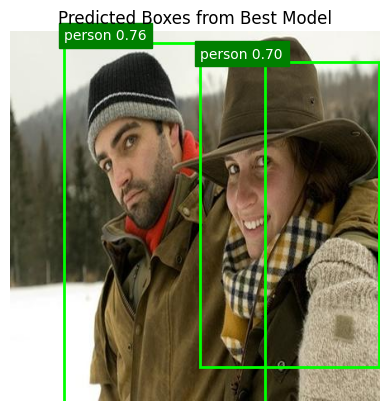

In [ ]:
import os
from PIL import Image
import torchvision.transforms as T
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch

VOC_LABELS = list(VOC_CLASSES.keys())

def predict_boxes(output, threshold=0.2, S=7, B=2, C=20):
    boxes = []
    output = output.detach().cpu().squeeze(0)  
    for i in range(S):
        for j in range(S):
            cell = output[i, j]
            objectness = cell[0]
            if objectness > threshold:
                x = (cell[1] + j) / S
                y = (cell[2] + i) / S
                w = cell[3]
                h = cell[4]
                class_id = torch.argmax(cell[10:]).item()
                boxes.append([x, y, w, h, class_id, objectness.item()])
    return boxes


img_path = os.path.join("/content/train", os.listdir("/content/train")[12])
image = Image.open(img_path).convert("RGB")

transform = T.Compose([
    T.Resize((448, 448)),
    T.ToTensor()
])
input_tensor = transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(input_tensor)

boxes = predict_boxes(output, threshold=0.2)


fig, ax = plt.subplots(1)
ax.imshow(image)

for box in boxes:
    x, y, w, h, class_id, conf = box
    x1 = (x - w / 2) * 448
    y1 = (y - h / 2) * 448
    width = w * 448
    height = h * 448

    rect = patches.Rectangle((x1, y1), width, height, linewidth=2, edgecolor='lime', facecolor='none')
    ax.add_patch(rect)
    ax.text(x1, y1 - 5, f"{VOC_LABELS[class_id]} {conf:.2f}", color='white', backgroundcolor='green')

plt.axis("off")
plt.title("Predicted Boxes from Best Model")
plt.show()
